In [1]:
%matplotlib widget
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd


/Users/mrvarshney/Codes/ARIES/venv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
df = pd.read_csv('/Users/mrvarshney/Codes/ARIES2/data/differential_lightcurves/1904_diff_timeseries.csv', delimiter = ',')
time = df['JD']
flux = 10**(-0.4 * df['DIFF_MAG'])
flux_err = 10**(-0.4 * df['DIFF_ERR'])

lc = lk.LightCurve(time = time, flux = df['DIFF_MAG']).normalize()

(0.5, 1.5)

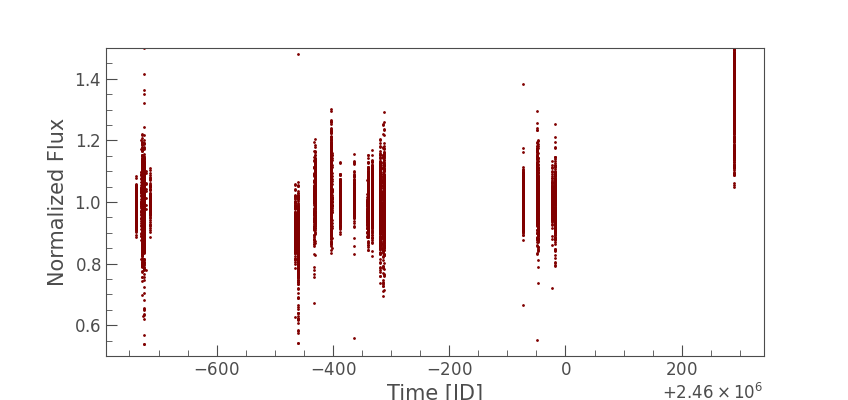

In [3]:
lc.plot(color = 'maroon', marker = '.', lw = 0)
plt.ylim(0.5,1.5)

<Axes: xlabel='Frequency [$\\mathrm{\\frac{1}{d}}$]', ylabel='Power'>

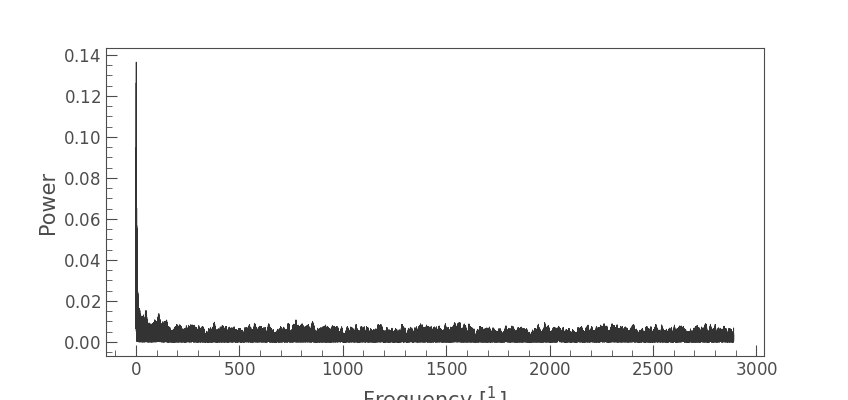

In [4]:
pg = lc.to_periodogram()
pg.plot()

In [5]:
best_period = pg.period_at_max_power
print(best_period)

0.9976332178887783 d


<Axes: xlabel='Phase (Normalized)', ylabel='Normalized Flux'>

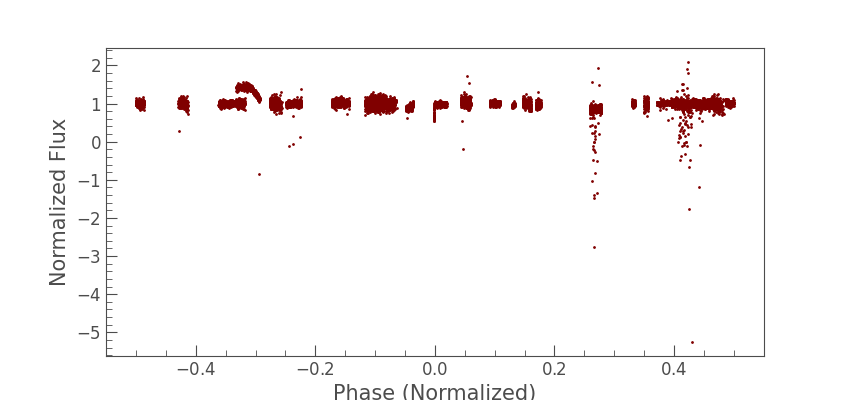

In [12]:
import astropy.units as u

epoch_time = (2.46e6 - 450) * u.day
lc_phased = lc.fold(3.81288, normalize_phase=True)
lc_phased.plot(linewidth =0, color = 'maroon', marker = '.')

In [13]:
lc_phased_binned = lc_phased.bin(5/60/24)

(0.8, 1.3)

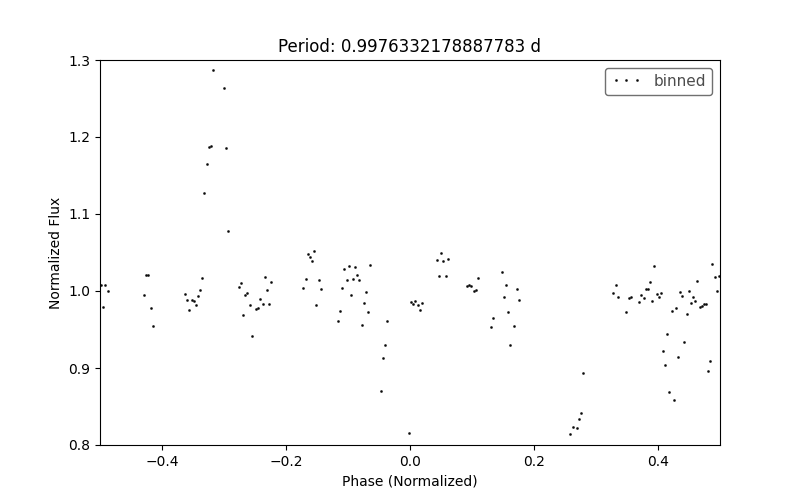

In [14]:
fig, ax = plt.subplots(figsize = (8,5))

#lc_phased.plot(ax = ax, marker = '.', linewidth = 0, color = 'red', alpha = 0.2, markersize = 3, label = 'unbinned')
lc_phased_binned.plot(
    ax=ax,
    linestyle='',     
    marker='o',
    color='black',
    markersize=1,
    alpha=0.8,
    label='binned',
)

# set x and y axis limits (for different targets these limits will be different!)
plt.xlim(-0.5,0.5)
plt.title(f"Period: {best_period}")

plt.ylim(0.8,1.3)
